# Visualize mSWE-GNN results — Ahr river (warmstart, additionalsrc_velocity, 100 m SFINCS run)

Ground truth: `ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart`  
Grid: 100 m resolution, hourly time steps. Includes velocity u/v.

**Workflow**
1. **Step 1a** — Reuse the existing 100 m mesh template (GIS files from non-warmstart run, same domain).
2. **Step 1b** — Convert the warmstart SFINCS run to a `.pkl` dataset (WD + velocity u/v).
3. Load dataset + model, run inference, visualise.

In [81]:
import sys
print(sys.executable)


c:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\python.exe


In [82]:
import sys, os

# Set PROJ database path before any geopandas/pyproj import so CRS lookups work.
_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Paths

In [83]:
WARMSTART_DIR  = os.path.join(REPO_ROOT, 'database', 'raw_datasets_ahr', 'Simulations',
                              'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart')
# GIS files (domain boundary + DEM) borrowed from non-warmstart run — identical domain geometry.
# Warmstart gis/ files may not be locally synced (OneDrive Files On-Demand).
NONWS_GIS_DIR  = os.path.join(REPO_ROOT, 'database', 'raw_datasets_ahr', 'Simulations',
                              'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon', 'gis')

SFINCS_MAP     = os.path.join(WARMSTART_DIR, 'sfincs_map.nc')
SFINCS_SRC     = os.path.join(WARMSTART_DIR, 'sfincs.src')
SFINCS_DIS     = os.path.join(WARMSTART_DIR, 'sfincs.dis')
SHAPEFILE      = os.path.join(NONWS_GIS_DIR, 'region.geojson')   # same domain boundary
DEM_TIF        = os.path.join(NONWS_GIS_DIR, 'dep.tif')          # same DEM

TEMPLATE_100M          = 'database/datasets/train/template_100m.pkl'
DATASET_NAME           = 'ahr_river_v03_marg_additionalsrc_velocity_100m_cutpolygon_warmstart'
OUT_ROOT               = 'database/datasets'

FORCE_REBUILD_TEMPLATE = False   # set True only to regenerate the shared mesh template
FORCE_REBUILD_PKL      = True    # rebuild PKL from warmstart simulation

for p in [SFINCS_MAP, SFINCS_SRC, SFINCS_DIS, SHAPEFILE, DEM_TIF]:
    print('OK  ' if os.path.exists(p) else 'MISSING', p)

OK   c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart\sfincs_map.nc
OK   c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart\sfincs.src
OK   c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart\sfincs.dis
OK   c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon\gis\region.geojson
OK   c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simul

In [84]:
import xarray as xr
import numpy as np

# Check both the repo copy and the original SFINCS folder
ORIGINAL_SFINCS_MAP = r'C:\Users\marrocol\OneDrive - Stichting Deltares\Documents\SFINCS\ahr_river_v03_Marg_additionalsrc_100m_cutpolygon\sfincs_map.nc'

for label, path in [('REPO COPY', SFINCS_MAP), ('ORIGINAL', ORIGINAL_SFINCS_MAP)]:
    if not os.path.exists(path):
        print(f'{label}: MISSING {path}')
        continue
    ds = xr.open_dataset(path, decode_times=False)
    zs = ds['zs'].values  # [T, n, m]
    msk = ds['msk'].values if 'msk' in ds else None
    # Count cells that ever have zs > 0.05 m (flooded)
    flooded = (zs > 0.05).any(axis=0)
    n_flooded = int(flooded.sum())
    zs_peak = float(np.nanmax(zs))
    print(f'{label}: shape={zs.shape}  peak_zs={zs_peak:.2f} m  ever-flooded cells={n_flooded}')
    ds.close()

REPO COPY: shape=(119, 258, 332)  peak_zs=322.04 m  ever-flooded cells=2567
ORIGINAL: shape=(119, 258, 332)  peak_zs=322.04 m  ever-flooded cells=2568


## Step 1a — Create 100 m mesh template
Uses `region.geojson` as the domain boundary, `dep.tif` as the DEM, and `sfincs_map.nc` as the finest mesh level.  
Coarser levels are built with gmsh — install first if needed: `pip install gmsh pygmsh`

In [85]:
if FORCE_REBUILD_TEMPLATE and os.path.exists(TEMPLATE_100M):
    os.remove(TEMPLATE_100M)
    print(f'Deleted stale template: {TEMPLATE_100M}')

if os.path.exists(TEMPLATE_100M):
    print(f'Template already exists: {TEMPLATE_100M}\nSkipping.')
else:
    from database.create_mesh_template_marg import create_mesh_template_pkl

    # Use non-warmstart sfincs_map.nc for grid structure — same grid, but stored in
    # standard axis-array format (avoid warmstart flat-coordinate format issue).
    NONWS_SFINCS_MAP = os.path.join(REPO_ROOT, 'database', 'raw_datasets_ahr', 'Simulations',
                                    'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon',
                                    'sfincs_map.nc')

    create_mesh_template_pkl(
        shapefile_path        = SHAPEFILE,
        dem_tif_path          = DEM_TIF,
        output_pkl_path       = TEMPLATE_100M,
        with_multiscale       = True,
        number_of_multiscales = 4,
        mesh_resolutions      = [2000, 1000, 500],
        sfincs_map_nc         = NONWS_SFINCS_MAP,
    )
    print(f'Template saved: {TEMPLATE_100M}')

Template already exists: database/datasets/train/template_100m.pkl
Skipping.


## Step 1b — Convert SFINCS 100 m run → .pkl dataset
Interpolates the SFINCS water depth onto the 100 m template mesh and saves train/test pkls.

In [86]:
import copy, pickle
import xarray as xr
from scipy.interpolate import griddata
from database.convert_sfincs_to_pkl_marg import (
    load_single_data_object, get_target_points,
    parse_src_file, parse_dis_file, build_output_data,
)

if FORCE_REBUILD_PKL:
    for split in ('train', 'test'):
        p = os.path.join(OUT_ROOT, split, f'{DATASET_NAME}.pkl')
        if os.path.exists(p):
            os.remove(p)
            print(f'Deleted stale dataset: {p}')

test_pkl = os.path.join(OUT_ROOT, 'test', f'{DATASET_NAME}.pkl')
if os.path.exists(test_pkl):
    print(f'Dataset already exists: {test_pkl}\nSkipping.')
else:
    print('Loading 100 m template mesh...')
    template_data = load_single_data_object(TEMPLATE_100M)
    target_points = get_target_points(template_data)
    num_targets   = target_points.shape[0]
    print(f'  Target mesh faces: {num_targets}')

    print('Opening warmstart SFINCS map...')
    ds = xr.open_dataset(SFINCS_MAP, decode_times=False)

    msk = ds['msk'].values
    zs  = ds['zs'].values                      # [T, n_rows, n_cols]
    zb  = ds['zb'].values                      # [n_rows, n_cols]

    if msk.ndim == 1:
        msk = msk.reshape(zs.shape[1], zs.shape[2])

    x = ds.coords['x'].values
    y = ds.coords['y'].values
    if x.ndim == 1 and y.ndim == 1:
        if len(x) == msk.shape[1] and len(y) == msk.shape[0]:
            x, y = np.meshgrid(x, y, indexing='xy')
        elif x.shape[0] == msk.size:
            x = x.reshape(msk.shape)
            y = y.reshape(msk.shape)

    active        = msk > 0
    source_points = np.column_stack([x[active], y[active]])
    print(f'  Active source cells: {source_points.shape[0]}  (total grid: {msk.size})')

    time_var    = ds.coords.get('time', ds.coords.get('t', None))
    map_times_s = time_var.values.astype(np.float64) if time_var is not None \
                  else np.arange(zs.shape[0]) * 3600.0
    print(f'  Time steps: {len(map_times_s)}  ({map_times_s[0]:.0f} - {map_times_s[-1]:.0f} s)')

    # --- WD ---
    print('Computing WD on active cells...')
    zs_active = zs[:, active]
    zb_active = zb[active]
    zs_filled = np.where(np.isnan(zs_active), zb_active[None, :], zs_active)
    WD_active = np.maximum(zs_filled - zb_active[None, :], 0.0).astype(np.float32)
    print(f'  Peak WD: {WD_active.max():.3f} m  |  ever-flooded: {(WD_active > 0.05).any(axis=0).sum()} cells')

    time_steps = WD_active.shape[0]
    WD_out = np.zeros((num_targets, time_steps), dtype=np.float32)
    print('Interpolating WD to mesh...')
    for t in range(time_steps):
        iv = griddata(source_points, WD_active[t], target_points, method='linear')
        WD_out[:, t] = np.nan_to_num(iv, nan=0.0)
    WD = WD_out
    del WD_active, zs_active, zs_filled, zs, zb
    ds.close()
    print(f'  WD done: shape={WD.shape}')

    # --- Velocities u/v ---
    ds_raw = xr.open_dataset(SFINCS_MAP, decode_times=False, mask_and_scale=False)
    VX = np.zeros((num_targets, time_steps), dtype=np.float32)
    VY = np.zeros((num_targets, time_steps), dtype=np.float32)

    if 'u' in ds_raw.data_vars:
        print('Interpolating velocity u...')
        u_raw  = ds_raw['u'].values.astype(np.float32)
        fill_u = ds_raw['u'].attrs.get('_FillValue', None)
        if fill_u is not None:
            u_raw[u_raw == float(fill_u)] = np.nan
        u_active = u_raw[:, active]
        del u_raw
        for t in range(time_steps):
            ok = np.isfinite(u_active[t])
            if ok.sum() > 3:
                iv = griddata(source_points[ok], u_active[t][ok], target_points, method='linear')
                VX[:, t] = np.nan_to_num(iv, nan=0.0)
        del u_active
        print('  VX done.')
    else:
        print('Velocity u not found -- using zeros.')

    if 'v' in ds_raw.data_vars:
        print('Interpolating velocity v...')
        v_raw  = ds_raw['v'].values.astype(np.float32)
        fill_v = ds_raw['v'].attrs.get('_FillValue', None)
        if fill_v is not None:
            v_raw[v_raw == float(fill_v)] = np.nan
        v_active = v_raw[:, active]
        del v_raw
        for t in range(time_steps):
            ok = np.isfinite(v_active[t])
            if ok.sum() > 3:
                iv = griddata(source_points[ok], v_active[t][ok], target_points, method='linear')
                VY[:, t] = np.nan_to_num(iv, nan=0.0)
        del v_active
        print('  VY done.')
    else:
        print('Velocity v not found -- using zeros.')

    ds_raw.close()

    # ── Boundary conditions ────────────────────────────────────────────────
    # BC structure — matches the non-warmstart training pkl exactly:
    #   type_BC = 2  (discharge -> VX slot in apply_boundary_condition)
    #   n_bc    = 7  (face_bnd cells at the 7 sfincs.src discharge injection points)
    #   BC[:,:,1]   = Q [m^3/s] from sfincs.dis, interpolated to map time steps
    #
    # The 87 outlet ghost cells are NOT in node_BC (not in training data either).
    # ──────────────────────────────────────────────────────────────────────────
    src_xy = parse_src_file(SFINCS_SRC)
    dis_times_s, discharge = parse_dis_file(SFINCS_DIS)
    print(f'  {len(src_xy)} source points  |  Q peak: {discharge.max():.1f} m^3/s')

    # build_output_data with src/dis args: maps src->face_bnd, interpolates Q, sets type_BC=2
    data_out = build_output_data(template_data, WD=WD, VX=VX, VY=VY,
                                 map_times_s=map_times_s,
                                 src_xy=src_xy, dis_times_s=dis_times_s, discharge=discharge)

    print(f'\n  BC summary:')
    print(f'    node_BC shape : {tuple(data_out.node_BC.shape)}  (7 discharge inflow nodes)')
    print(f'    BC shape      : {tuple(data_out.BC.shape)}')
    print(f'    type_BC       : {data_out.type_BC.item()} (2 = discharge -> VX slot)')
    print(f'    Q peak        : {data_out.BC[:,:,1].max().item():.1f} m^3/s')
    print(f'    node_BC       : {data_out.node_BC.tolist()}')

    for split in ('train', 'test'):
        out_dir  = os.path.join(OUT_ROOT, split)
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f'{DATASET_NAME}.pkl')
        with open(out_path, 'wb') as f:
            pickle.dump([copy.deepcopy(data_out)], f)
        print(f'  Saved: {out_path}')

    print(f'\nDone.  WD={tuple(data_out.WD.shape)}  VX={tuple(data_out.VX.shape)}  VY={tuple(data_out.VY.shape)}')

Deleted stale dataset: database/datasets\train\ahr_river_v03_marg_additionalsrc_velocity_100m_cutpolygon_warmstart.pkl
Deleted stale dataset: database/datasets\test\ahr_river_v03_marg_additionalsrc_velocity_100m_cutpolygon_warmstart.pkl
Loading 100 m template mesh...
  Target mesh faces: 30079
Opening warmstart SFINCS map...
  Active source cells: 24994  (total grid: 85656)
  Time steps: 119  (0 - 424800 s)
Computing WD on active cells...
  Peak WD: 10.722 m  |  ever-flooded: 2535 cells
Interpolating WD to mesh...
  WD done: shape=(30079, 119)
Interpolating velocity u...
  VX done.
Interpolating velocity v...
  VY done.
  7 source points  |  Q peak: nan m^3/s
  Mapped 7 source points to BOUNDARY mesh nodes: [17553 12285  5013  5366 10451  8674 11425]

  BC summary:
    node_BC shape : (7,)  (7 discharge inflow nodes)
    BC shape      : (7, 119, 2)
    type_BC       : 2 (2 = discharge -> VX slot)
    Q peak        : 450.0 m^3/s
    node_BC       : [17553, 12285, 5013, 5366, 10451, 8674

In [87]:
# ── BC sanity check ────────────────────────────────────────────────────────
# Reload the pkl and trace apply_boundary_condition() at t=0.
# Expected: type_BC=2, 7 nodes, Q values in VX slot.
import pickle, torch
from utils.dataset import apply_boundary_condition

with open(os.path.join(OUT_ROOT, 'test', f'{DATASET_NAME}.pkl'), 'rb') as f:
    _data = pickle.load(f)[0]

NUM_WATER_VARS = 3   # WD, VX, VY

print("=== Stored in pkl ===")
print(f"  node_BC  : {_data.node_BC.tolist()}")
print(f"  type_BC  : {_data.type_BC.item()}  (expect 2 = discharge)")
print(f"  BC shape : {tuple(_data.BC.shape)}  (expect [7, T, 2])")
print(f"  Q at t=0 : {_data.BC[:, 0, 1].tolist()}  m^3/s")
print(f"  Q peak   : {_data.BC[:,:,1].max().item():.1f} m^3/s  (expect ~450)")

print("\n=== What apply_boundary_condition() does at t=0 ===")
_x    = torch.zeros(_data.num_nodes, NUM_WATER_VARS)
_BC_t0 = _data.BC[:, 0, 1] / _data.edge_BC_length
_x_after = apply_boundary_condition(_x.clone(), _BC_t0.unsqueeze(-1), _data.node_BC, type_BC=_data.type_BC)
slot = _data.type_BC.item() - 1   # 1 -> slot 1 = VX
print(f"  Slot written: {slot}  ({'WD' if slot==0 else 'VX' if slot==1 else 'VY'})")
print(f"  x[node_BC, VX] after BC: {_x_after[_data.node_BC, 1].tolist()}")
print(f"  Nodes changed: {(_x_after[:, slot] != 0).sum().item()}  (expect 7)")

=== Stored in pkl ===
  node_BC  : [17553, 12285, 5013, 5366, 10451, 8674, 11425]
  type_BC  : 2  (expect 2 = discharge)
  BC shape : (7, 119, 2)  (expect [7, T, 2])
  Q at t=0 : [0.460999995470047, 2.1110000610351562, 2.7799999713897705, 0.6449999809265137, 0.0, 0.0, 0.0]  m^3/s
  Q peak   : 450.0 m^3/s  (expect ~450)

=== What apply_boundary_condition() does at t=0 ===
  Slot written: 1  (VX)
  x[node_BC, VX] after BC: [0.460999995470047, 2.1110000610351562, 2.7799999713897705, 0.6449999809265137, 0.0, 0.0, 0.0]
  Nodes changed: 4  (expect 7)


## Step 2 — Load config and dataset

In [88]:
cfg = read_config('config_finetune.yaml')

# Override dataset name to point at the 100 m run
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')   # change to 'cuda' if GPU is available
print('Test dataset:', config.dataset_parameters['test_dataset_name'])

Test dataset: ahr_river_v03_marg_additionalsrc_velocity_100m_cutpolygon_warmstart


In [89]:
_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)
print('Test size:', len(test_dataset))
print('Mesh type:', type(test_dataset[0].mesh).__name__)
print('WD shape: ', test_dataset[0].WD.shape)
print('Scalers:  ', scalers)

The validation dataset you are using is the training one. Careful!
Test size: 1
Mesh type: MultiscaleMesh
WD shape:  torch.Size([30079, 119])
Scalers:   {'DEM_scaler': StandardScaler(), 'slope_scaler': None, 'area_scaler': [StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()], 'edge_length_scaler': [StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()], 'edge_slope_scaler': None, 'WD_scaler': None, 'V_scaler': None}


## Step 3 — Inspect mesh levels

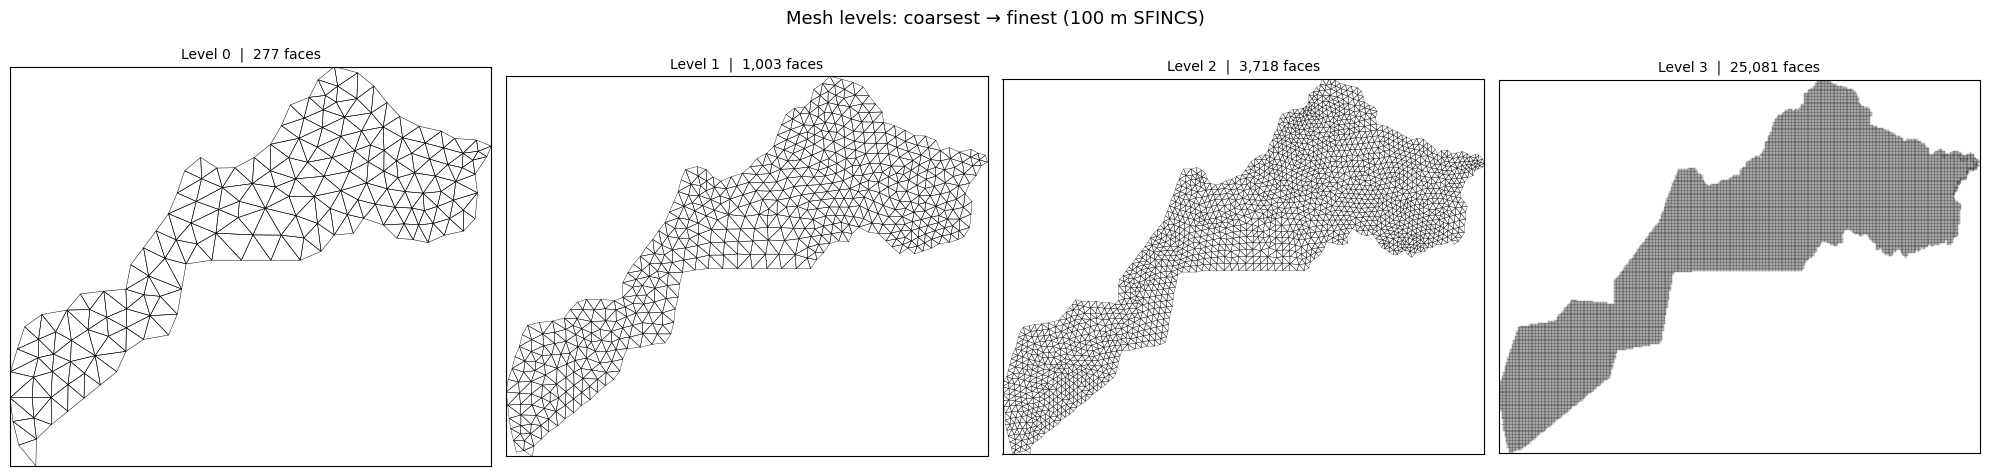

In [90]:
from database.graph_creation import plot_faces

meshes = test_dataset[0].mesh.meshes
n = len(meshes)

fig, axs = plt.subplots(1, n, figsize=(n * 5, 5))
fig.suptitle('Mesh levels: coarsest → finest (100 m SFINCS)', fontsize=13)

for i, m in enumerate(meshes):
    ax = axs[i] if n > 1 else axs
    lw = max(0.05, 0.35 - i * 0.07)
    plot_faces(m, ax=ax, facecolor='none', edgecolor='black', linewidth=lw)
    ax.set_aspect('equal')
    ax.set_title(f'Level {i}  |  {m.face_x.shape[0]:,} faces', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 4 — Load model

In [91]:
temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)
print(f'num_node_features: {num_node_features},  num_edge_features: {num_edge_features}')

model_parameters = dict(config.models)
model_type = model_parameters.pop('model_type')

if model_type == 'MSGNN':
    model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

model = get_model(model_type)(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    previous_t=temporal_test_dataset_parameters['previous_t'],
    device=device,
    **model_parameters
).to(device)

plmodule_kwargs = {
    'model': model,
    'lr_info': config['lr_info'],
    'trainer_options': config.trainer_options,
    'temporal_test_dataset_parameters': temporal_test_dataset_parameters
}

plmodule = LightningTrainer.load_from_checkpoint(
    config.saved_model, map_location=device, **plmodule_kwargs
)
model = plmodule.model.to(device)
model.eval()
print('Model loaded from:', config.saved_model)

num_node_features: 8,  num_edge_features: 1
Model loaded from: results/finetuned_dk15.h5


## Step 5 — Run inference

In [92]:
plot_rollout = PlotRollout(
    model,
    test_dataset[0],
    scalers=scalers,
    **temporal_test_dataset_parameters
)
print('PlotRollout ready. Total time steps:', plot_rollout.real_rollout.shape[-1])

PlotRollout ready. Total time steps: 118


In [93]:
# import xarray as xr

# # Load the 100 m SFINCS run (same file used to build the dataset)
# ds  = xr.open_dataset(SFINCS_MAP, decode_times=False)
# msk = ds['msk'].values          # (n_rows, n_cols)
# x   = ds.coords['x'].values
# y   = ds.coords['y'].values
# if x.ndim == 1:
#     x, y = np.meshgrid(x, y, indexing='xy')
# zb  = ds['zb'].values           # bed elevation (n_rows, n_cols)
# zs  = ds['zs'].values           # water surface elevation [T, n_rows, n_cols]

# active = msk > 0
# x_active = x[active]
# y_active = y[active]
# zb_active = zb[active]

In [94]:
# from utils.visualization import plot_faces

# t_idx = 60   # hour — change to inspect any time step (0–120)

# # WD = max(zs - zb, 0) on active cells only
# wd_active = np.maximum(zs[t_idx][active] - zb_active, 0.0)

# fig, ax = plt.subplots(figsize=(8, 6))
# plot_faces(test_dataset[0].mesh.meshes[-1], face_value=None, ax=ax)
# sc = ax.scatter(x_active, y_active, c=wd_active, cmap='Blues', s=1, vmin=0)
# plt.colorbar(sc, ax=ax, label='WD [m]')
# ax.set_title(f'SFINCS ground truth WD — t = {t_idx} h')
# ax.set_xlim(x_active.min(), x_active.max())
# ax.set_ylim(y_active.min(), y_active.max())
# plt.tight_layout()
# plt.show()

In [95]:
# zs[-1][zs[-1] != np.nan]

In [96]:
#zs

## Step 6 — Visualise

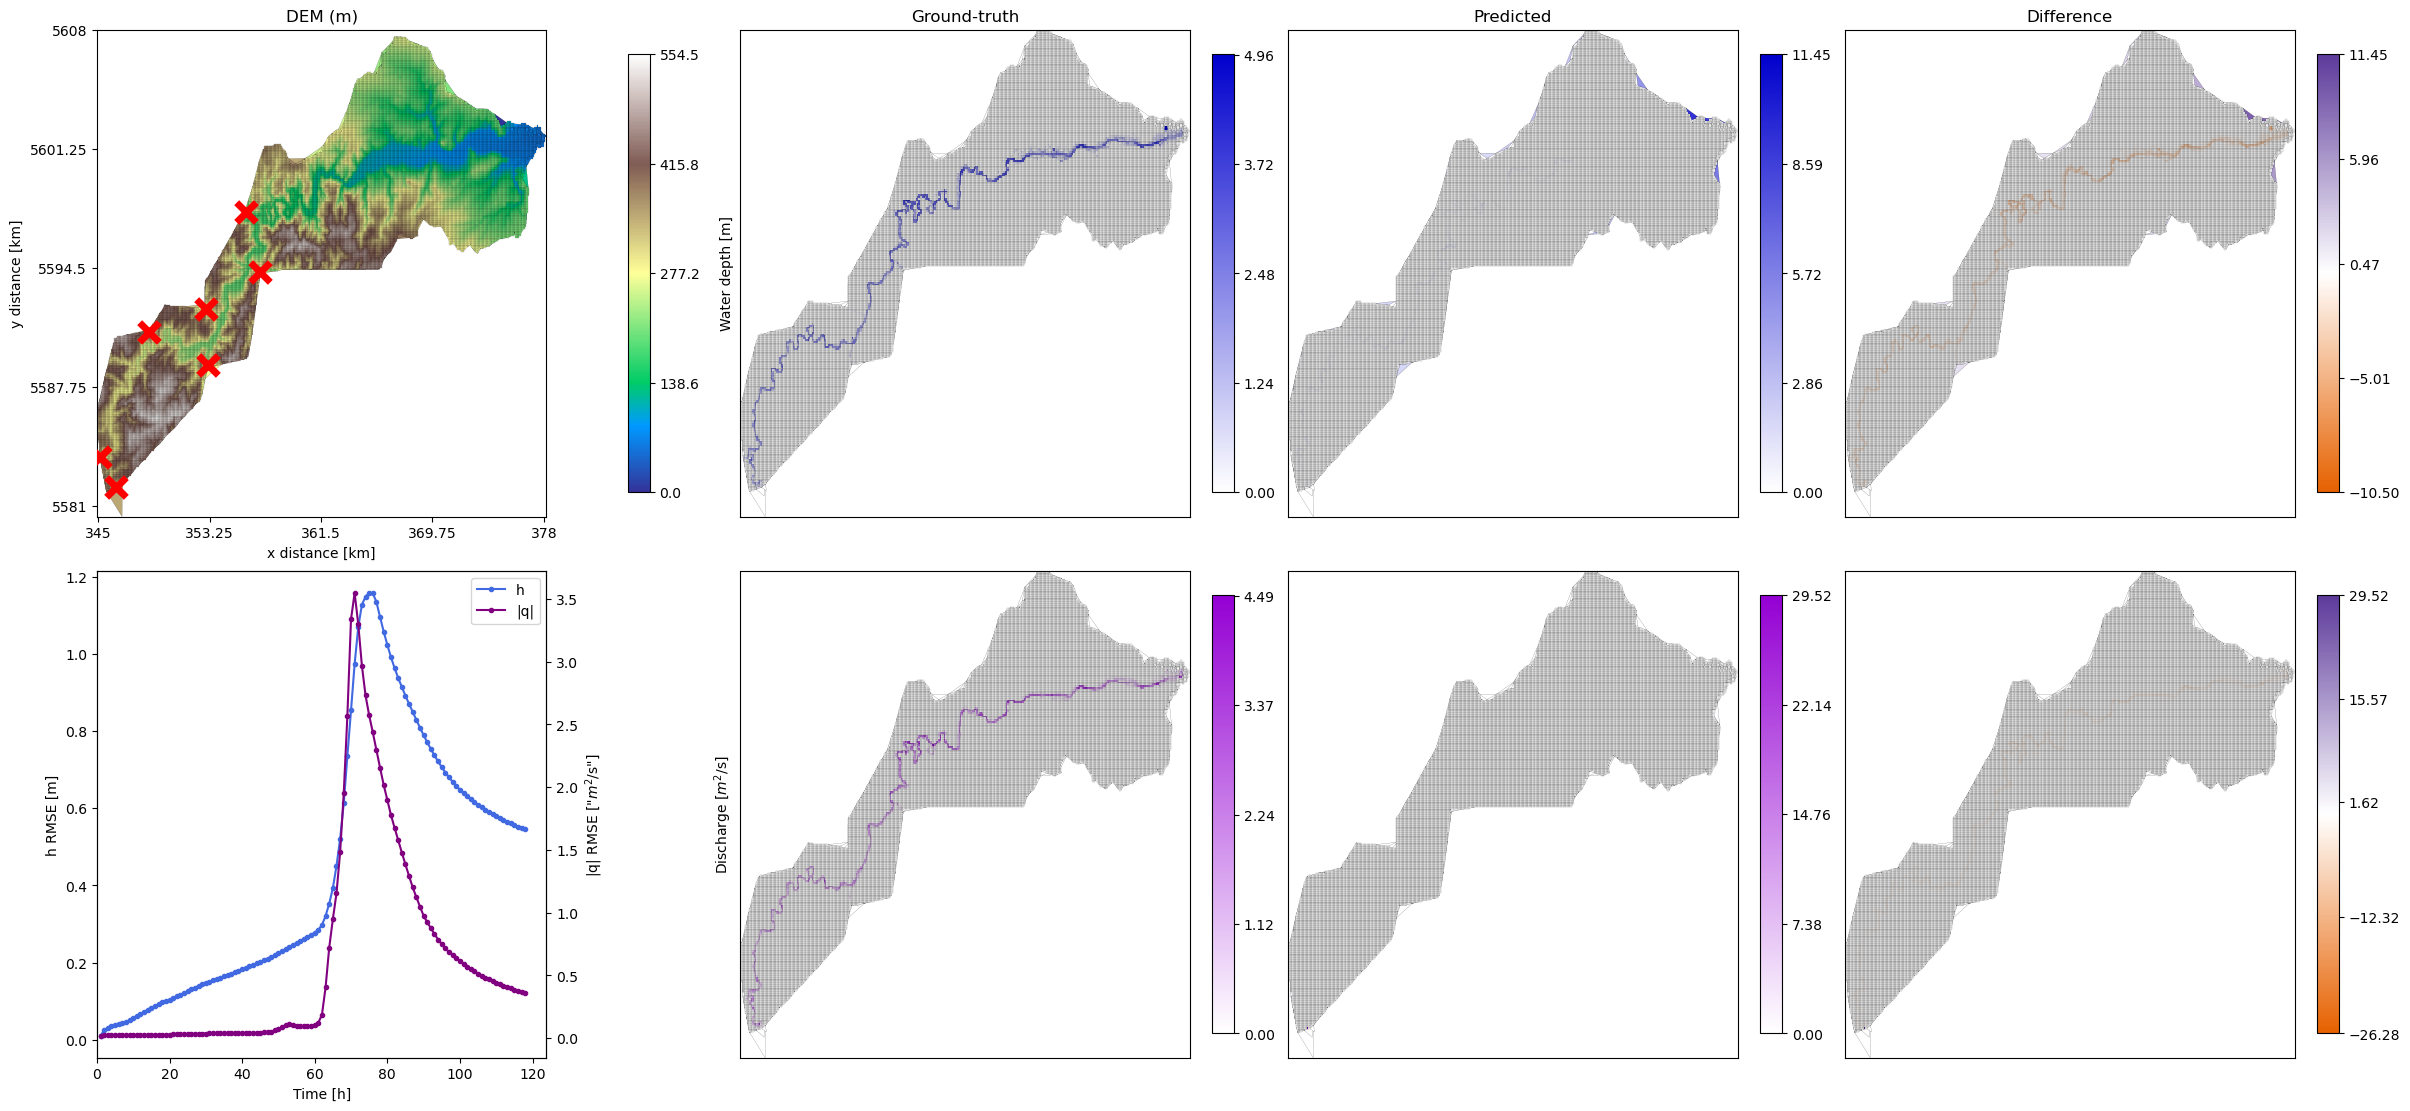

In [97]:
# Snapshot at the last time step (DEM, SFINCS ground truth, prediction, difference)
fig = plot_rollout.explore_rollout(time_step=-1)
plt.show()

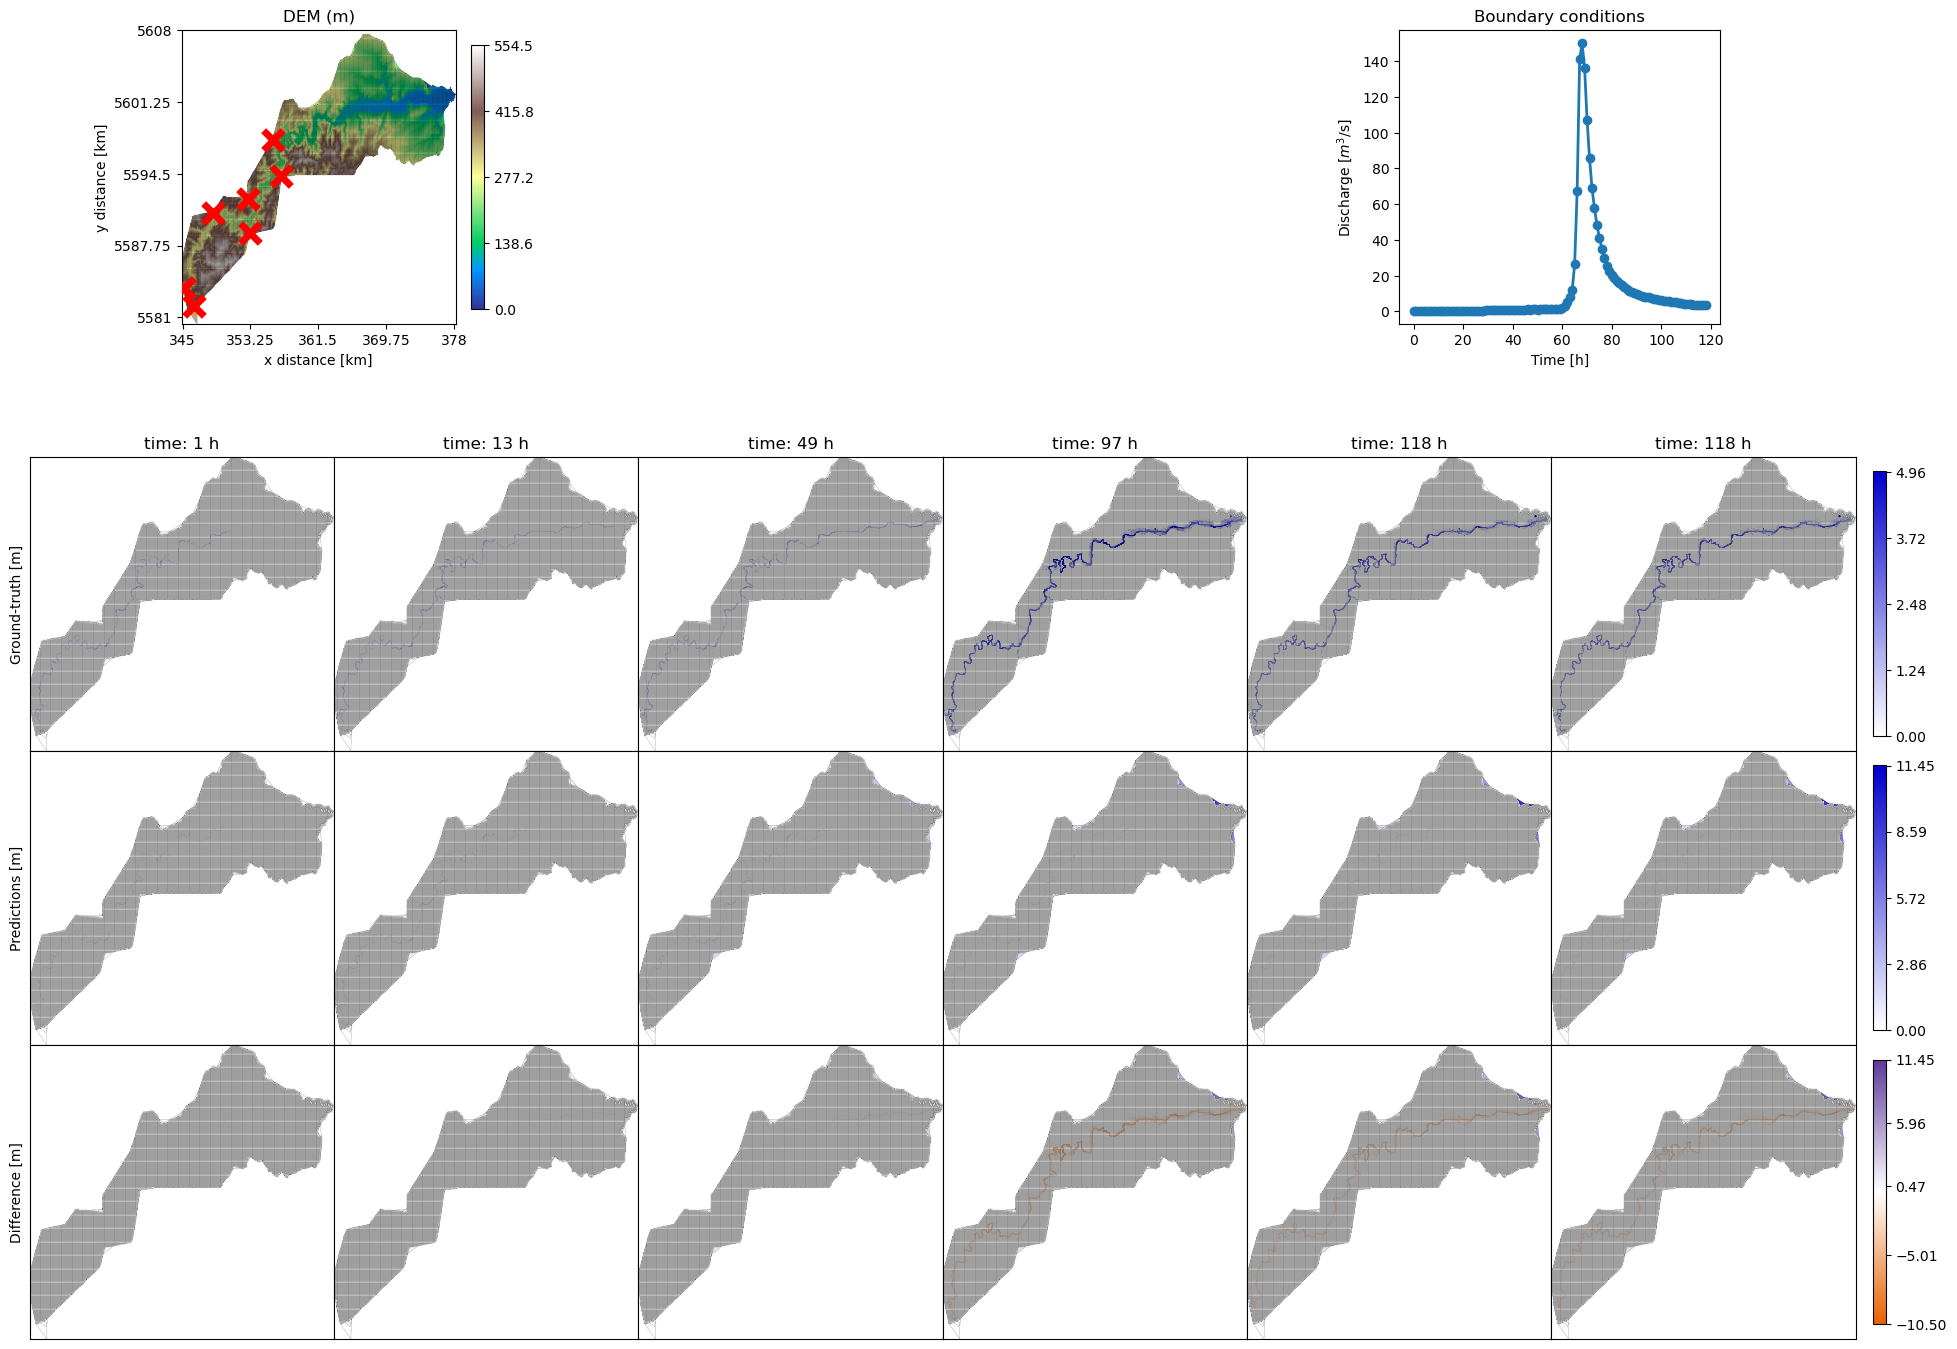

In [98]:
n_steps = plot_rollout.real_rollout.shape[-1]
plot_times = [0, 12, 48, 96, n_steps - 1]
plot_rollout.compare_h_rollout(plot_times=plot_times)
plt.show()

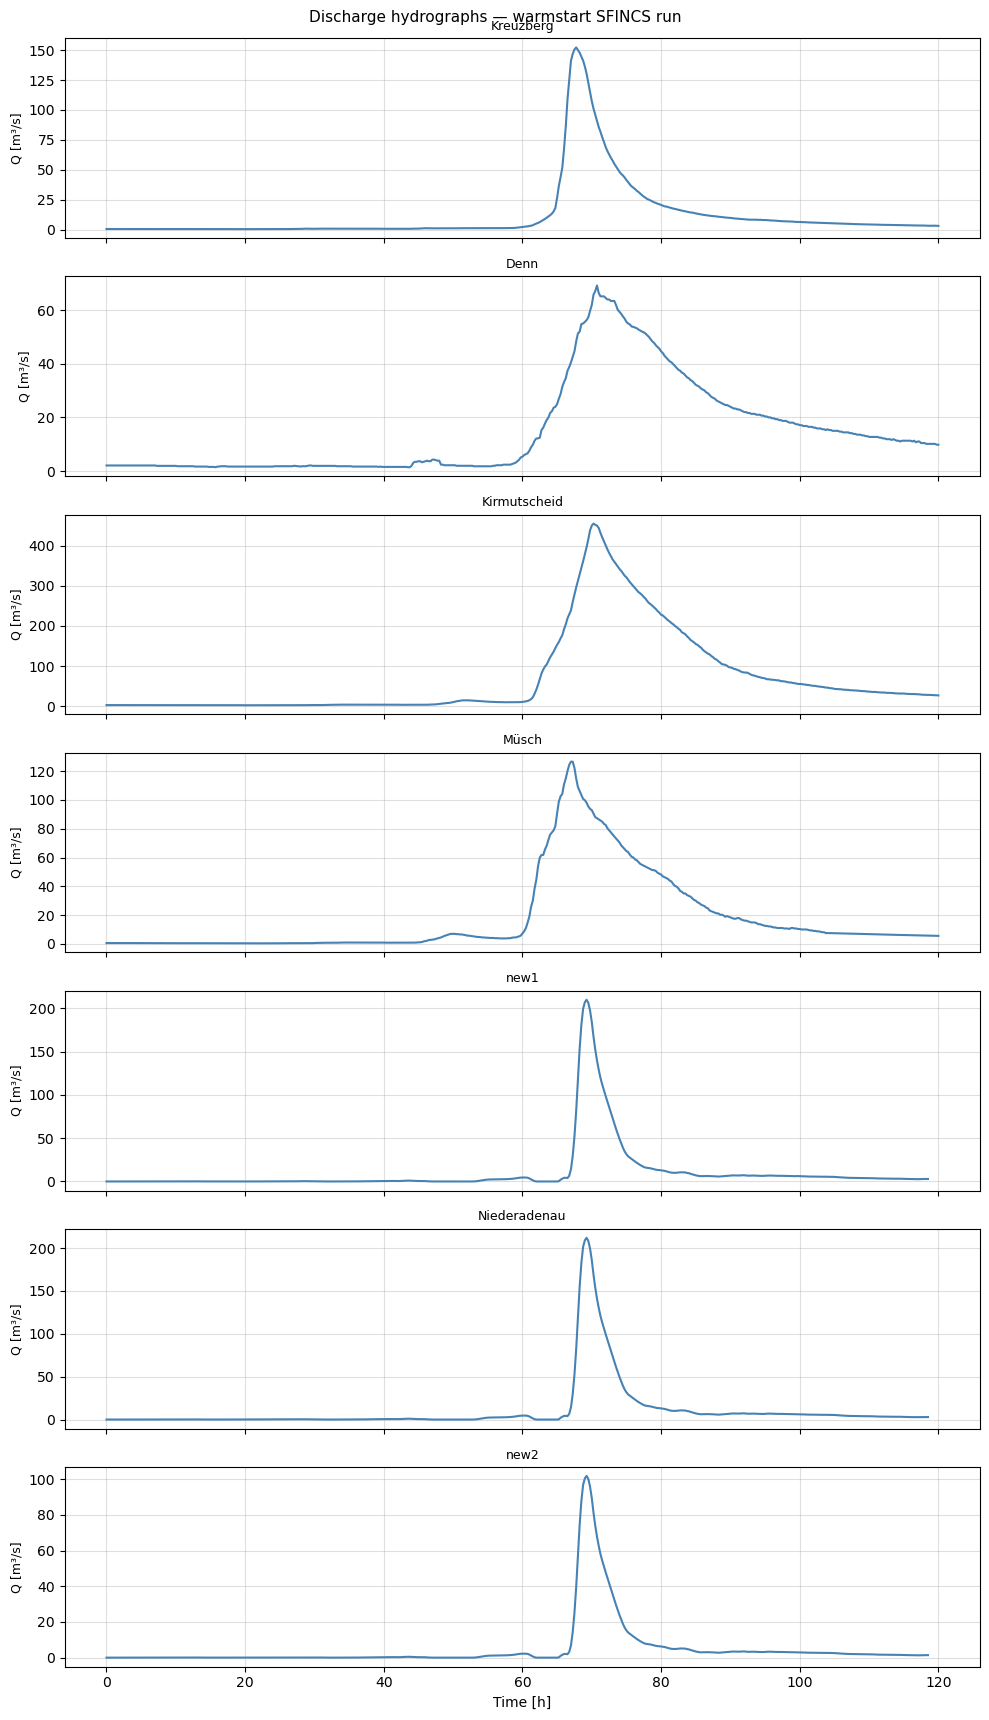

In [99]:
# Source discharge hydrographs — read directly from sfincs.dis (independent of BC encoding)
from database.convert_sfincs_to_pkl_marg import parse_src_file, parse_dis_file

src_names = ['Kreuzberg', 'Denn', 'Kirmutscheid', 'Müsch', 'new1', 'Niederadenau', 'new2']
src_xy                 = parse_src_file(SFINCS_SRC)
dis_times_s, discharge = parse_dis_file(SFINCS_DIS)

t_hours = dis_times_s / 3600.0
n_src   = discharge.shape[1]

fig, axes = plt.subplots(n_src, 1, figsize=(10, 2.5 * n_src), sharex=True, facecolor='white')
for i, ax in enumerate(axes):
    ax.plot(t_hours, discharge[:, i], color='steelblue')
    ax.set_ylabel('Q [m³/s]', fontsize=9)
    ax.set_title(src_names[i] if i < len(src_names) else f'source {i}', fontsize=9)
    ax.grid(True, alpha=0.4)
axes[-1].set_xlabel('Time [h]')
fig.suptitle('Discharge hydrographs — warmstart SFINCS run', fontsize=11)
fig.tight_layout()
plt.show()

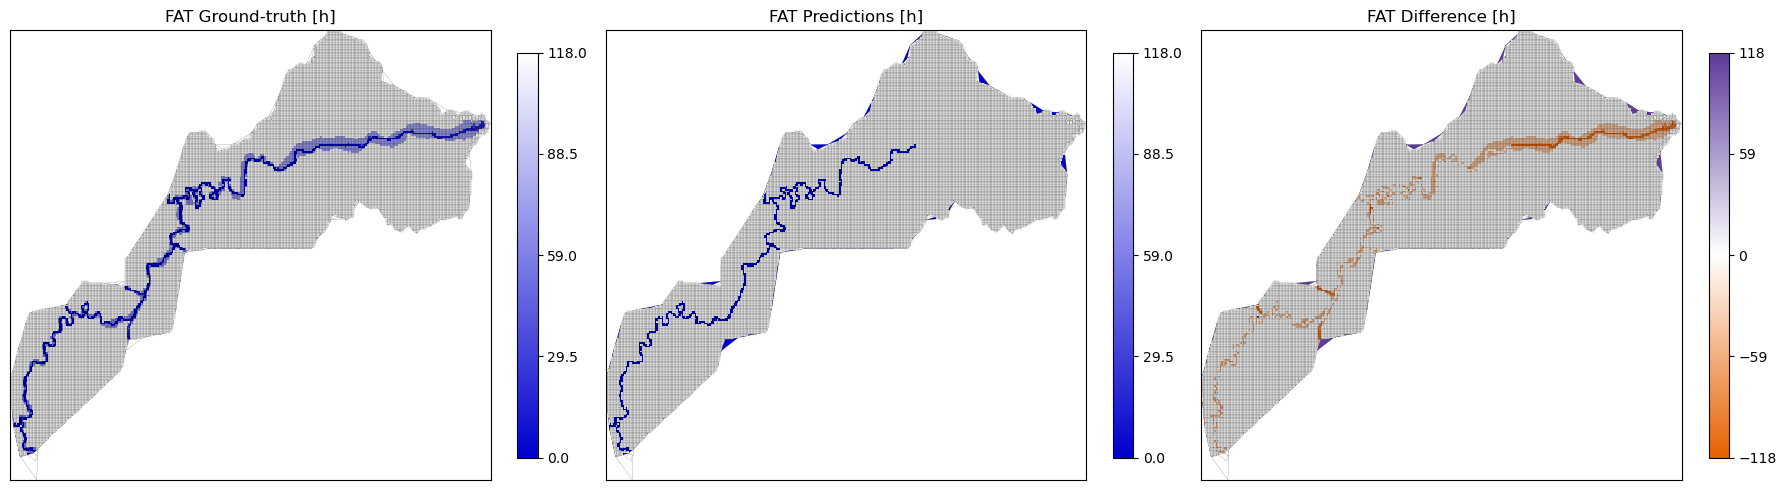

In [100]:
# Flood arrival time comparison
plot_rollout.compare_FAT(water_threshold=0.05)
plt.show()

In [101]:
# Quantitative metrics
rollout_loss = plot_rollout._get_rollout_loss(type_loss='MAE')
loss_mean = rollout_loss.mean(0)
print('rollout_loss shape:', rollout_loss.shape)
print(f'MAE WD:       {loss_mean[0].item():.4f} m' if loss_mean.dim() > 0 else f'MAE: {loss_mean.item():.4f}')
if loss_mean.dim() > 0 and loss_mean.shape[0] > 1:
    print(f'MAE V:        {loss_mean[1:].mean().item():.4f} m²/s')

csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
csi_03  = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()
print(f'CSI @ 0.05 m: {csi_005:.4f}')
print(f'CSI @ 0.30 m: {csi_03:.4f}')

rollout_loss shape: torch.Size([2])
MAE: 0.0904
CSI @ 0.05 m: 0.5285
CSI @ 0.30 m: 0.4022
